# Validating Landlab output against observations: Pioneer / Stehekin

Scores the 10 m Landlab fields against the 89 mapped debris-flow initiation points and the dDEM, and maps where they agree. Everything runs from this folder: **Run All**.

`landlab_grid_validation/` is the tool; `data/` holds the model output and the observations.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from landlab_grid_validation import (FieldSpec, compare_fields_on_grid, grid_from_raster,
                                     plot_comparison, raster_to_node_field, vector_to_node_field)

DATA = Path("data")
CRS = "EPSG:6339"   # NAD83(2011) / UTM 10N; the .asc files carry no CRS of their own

## 1. Landlab grid with the model fields

`grid_from_raster` puts every node at its cell centre. Loading these `.asc` files with `landlab.io.esri_ascii.load` instead puts nodes on cell corners (the header says `xllcorner`), half a cell off; the tool refuses such a grid rather than misplace the data.

In [2]:
grid, crs = grid_from_raster(DATA / "P_Landslide.asc", crs=CRS)

LAYERS = {"P_Landslide": "Landslide", "P_Channel_ini": "Channel initiation",
          "P_Combined_H": "Combined hillslope"}
for key in LAYERS:
    grid.add_field(key, raster_to_node_field(grid, crs, DATA / f"{key}.asc", raster_crs=CRS), at="node")
grid.add_field("MWR_dz", raster_to_node_field(grid, crs, DATA / "MWR.asc", raster_crs=CRS), at="node")
grid.add_field("dDEM_dz", raster_to_node_field(grid, crs, DATA / "ddem_10m_mean.tif"), at="node")
print(grid.shape, f"cells of {grid.dx:g} m", sorted(grid.at_node))

(423, 474) cells of 10 m ['MWR_dz', 'P_Channel_ini', 'P_Combined_H', 'P_Landslide', 'dDEM_dz']


## 2. Mapped points as fields on the same grid

Each point becomes a 3 x 3 block (30 m), the positional tolerance a remotely mapped point deserves. Negatives are the pseudo-absence blocks that hold no initiation of any type.

In [3]:
points = gpd.read_file(DATA / "initiation_points.shp").to_crs(crs)
EVIDENCE = {"LS": "Landslide", "Runoff": "Runoff", "Firehose": "Firehose", "All": "All types"}
observed = {c: vector_to_node_field(grid, crs, points if c == "All" else points[points.FailureTyp == c],
                                    tolerance_cells=1) for c in EVIDENCE}
absence = vector_to_node_field(grid, crs, DATA / "absence_points.shp", tolerance_cells=1)
negatives = (absence == 1) & (observed["All"] == 0)
{EVIDENCE[c]: int(v.sum()) for c, v in observed.items()} | {"negatives": int(negatives.sum())}

{'Landslide': 386,
 'Runoff': 198,
 'Firehose': 176,
 'All types': 758,
 'negatives': 808}

## 3. How well each probability layer ranks the mapped initiations

AUC: 0.5 is chance, 1 is perfect.

In [4]:
def score(field, code):
    return compare_fields_on_grid(
        grid, field, observed[code],
        FieldSpec(name=LAYERS[field], kind="continuous", units="probability", threshold=0.5),
        FieldSpec(name=f"{EVIDENCE[code]} initiations", kind="binary"),
        mask=(observed[code] == 1) | negatives,
    )

pd.DataFrame({LAYERS[f]: {EVIDENCE[c]: score(f, c).metrics["roc_auc"] for c in EVIDENCE}
              for f in LAYERS}).round(3)

,Landslide,Channel initiation,Combined hillslope
Landslide,0.538,0.593,0.610
Runoff,0.556,0.730,0.724
Firehose,0.670,0.693,0.715
All types,0.574,0.652,0.665


## 4. Map: landslide field vs landslide points

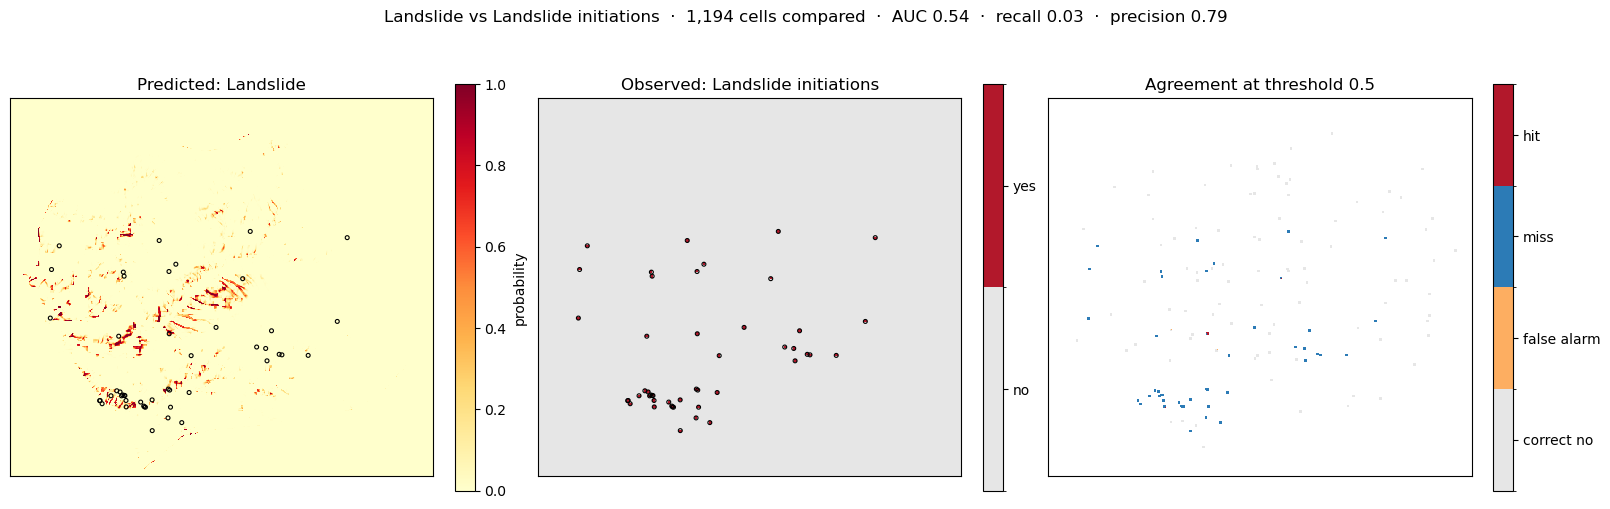

In [5]:
result = score("P_Landslide", "LS")
fig = plot_comparison(grid, result, points=points[points.FailureTyp == "LS"], marker_size=8)

## 5. MWR erosion vs dDEM erosion

Erosion means more than 0.5 m of loss. `MWR.asc` carries 45 cells flagged near 9999; `valid_range` removes them and reports the count. `tolerance_cells=1` adds recall and precision that forgive a one-cell offset. The dDEM gain side is not used: the post-event DEM is photogrammetric, so vegetation reads as gain.

/tmp/ipykernel_15543/14766568.py:4: UserWarning: MWR erosion depth: 45 values outside valid_range (-50, 50) set to no-data
  result = compare_fields_on_grid(


{'roc_auc': 0.528, 'recall': 0.091, 'precision': 0.134, 'recall_within_tolerance': 0.151, 'precision_within_tolerance': 0.31} | masked: {'predicted': 45, 'observed': 0}


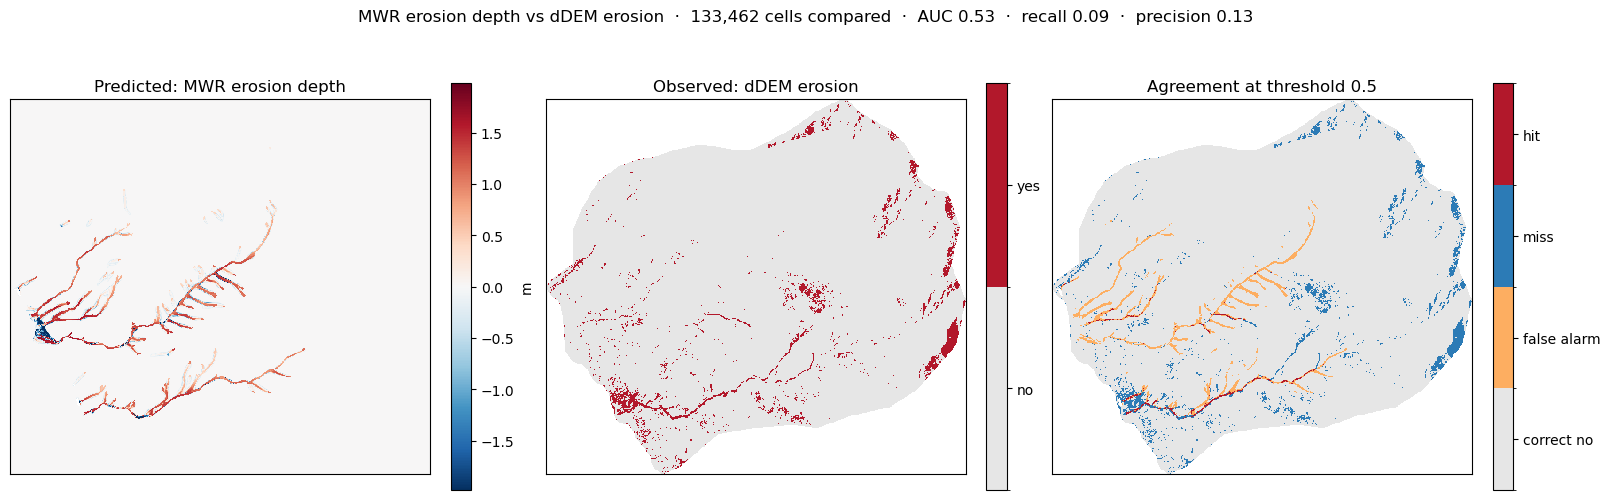

In [6]:
d = grid.at_node["dDEM_dz"]
ddem_erosion = np.where(np.isnan(d), np.nan, (d < -0.5).astype(float))

result = compare_fields_on_grid(
    grid, -grid.at_node["MWR_dz"], ddem_erosion,
    FieldSpec(name="MWR erosion depth", kind="continuous", units="m", threshold=0.5,
              valid_range=(-50, 50), sign_convention="positive_is_loss"),
    FieldSpec(name="dDEM erosion", kind="binary"),
    tolerance_cells=1,
)
keys = ("roc_auc", "recall", "precision", "recall_within_tolerance", "precision_within_tolerance")
print({k: round(result.metrics[k], 3) for k in keys}, "| masked:", result.masked_out_of_range)
fig = plot_comparison(grid, result)

## Your own output

Put the `.asc` in `data/`, add it as a field as in step 1, and score it as in step 3 or 5. The same calls work on any Landlab raster grid, for any fire.